In [1]:
import os
from pathlib import Path

import numpy as np
import scipy.io

from scipy.signal import butter, filtfilt, savgol_filter
from PIL import Image

In [7]:
PROJECT_DIR = Path(r"C:\Users\ankus\OneDrive\Documents\222026\IT\Awdhootprasad\Kurtosis\2D_CNN")

DATA_DIR = Path(r"C:\Users\ankus\OneDrive\Documents\222026\IT\Awdhootprasad\Kurtosis\Data\normal")

GASF_DIR = PROJECT_DIR / "GASF"
GADF_DIR = PROJECT_DIR / "GADF"

print("Data directory:", DATA_DIR)
print("Exists:", DATA_DIR.exists())

Data directory: C:\Users\ankus\OneDrive\Documents\222026\IT\Awdhootprasad\Kurtosis\Data\normal
Exists: True


In [8]:
def load_signal(file_path):

    data = scipy.io.loadmat(file_path)

    signal = None

    for key in data.keys():

        if key.endswith("_DE_time"):
            signal = data[key].flatten()
            break

    if signal is None:
        raise ValueError(f"No DE signal found in {file_path}")

    return signal.astype(np.float64)

In [9]:
def butterworth(signal, cutoff, fs, order=4):

    min_cut = fs / 2

    if cutoff >= min_cut:
        raise ValueError(
            f"Cutoff {cutoff} Hz must be lower than Nyquist frequency {min_cut} Hz"
        )

    b, a = butter(
        order,
        cutoff/min_cut,
        btype="high",
        analog=False
    )

    filtered = filtfilt(b, a, signal)

    return filtered

In [10]:
def s_enhancement(signal, k=6):

    signal = np.asarray(signal, dtype=np.float64)

    enhanced = np.zeros_like(signal)

    enhanced[1:-1] = ((signal[1:-1] - signal[:-2])**2 + (signal[1:-1] - signal[2:])**2)**(1/k)

    enhanced[0] = enhanced[1]
    enhanced[-1] = enhanced[-2]

    return enhanced

In [11]:
def savitzky_golay(signal):

    return savgol_filter(signal,window_length=11,polyorder=3)

In [12]:
def min_max_normalize(signal):

    min_val = np.min(signal)
    max_val = np.max(signal)

    if max_val == min_val:
        return np.zeros_like(signal)

    normalized = (2*(signal - min_val)/(max_val - min_val)) - 1

    return normalized

In [13]:
def polar_signal(signal):

    return np.arccos(signal)

In [14]:
def create_gasf(phi):

    gasf = np.cos(phi[:, None] + phi[None, :])

    return gasf

In [15]:
def create_gadf(phi):

    gadf = np.sin(phi[:, None] - phi[None, :])

    return gadf

In [ ]:
# WINDOW_SIZE = 1024

# TRAIN_STEP = 512       # 50% overlap
# VAL_STEP = 1024        # no overlap
# TEST_STEP = 1024       # no overlap

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# FS = 12000

# # Use the SAME cutoff you used in your previous experiment
# CUTOFF = 5000
# FS = 48000
# CUTOFF = 22000

WINDOW_SIZE = 1024
TRAIN_STEP = 512
VAL_STEP = 1024
TEST_STEP = 1024

In [18]:
def get_class_name(file_path, parent_folder):

    filename = Path(file_path).stem.upper()

    if parent_folder == "Ball fault":

        if filename.startswith("B007"):
            return "B_007"

        elif filename.startswith("B014"):
            return "B_014"

        elif filename.startswith("B021"):
            return "B_021"

    elif parent_folder == "Inner race":

        if filename.startswith("IR007"):
            return "IR_007"

        elif filename.startswith("IR014"):
            return "IR_014"

        elif filename.startswith("IR021"):
            return "IR_021"

    elif parent_folder == "Outer race":

        if filename.startswith("OR007"):
            return "OR_007"

        elif filename.startswith("OR014"):
            return "OR_014"

        elif filename.startswith("OR021"):
            return "OR_021"

    elif parent_folder.lower() == "normal":

        return "Normal"

    raise ValueError(
        f"Could not determine class for {file_path}"
    )

In [19]:
CLASSES = [
    "B_007",
    "B_014",
    "B_021",
    "IR_007",
    "IR_014",
    "IR_021",
    "OR_007",
    "OR_014",
    "OR_021",
    "Normal"
]

SPLITS = ["train", "val", "test"]

for base_dir in [GASF_DIR, GADF_DIR]:

    for split in SPLITS:

        for class_name in CLASSES:

            folder = base_dir / split / class_name

            folder.mkdir(
                parents=True,
                exist_ok=True
            )

print("Output folders created.")

Output folders created.


In [20]:
def get_windows(signal, is_normal=False):

    n = len(signal)

    train_end = int(0.70 * n)
    val_end = int(0.85 * n)

    splits = {}

    # -------------------------
    # NORMAL
    # -------------------------

    if is_normal:

        # TRAIN → exactly 165 windows
        train_windows = []

        max_start = train_end - WINDOW_SIZE

        train_starts = np.linspace(
            0,
            max_start,
            165,
            dtype=int
        )

        for start in train_starts:

            window = signal[start:start + WINDOW_SIZE]

            train_windows.append(window)

        splits["train"] = train_windows


        # VALIDATION → exactly 17 windows
        val_windows = []

        val_start = train_end
        max_start = val_end - WINDOW_SIZE

        val_starts = np.linspace(
            val_start,
            max_start,
            17,
            dtype=int
        )

        for start in val_starts:

            window = signal[start:start + WINDOW_SIZE]

            val_windows.append(window)

        splits["val"] = val_windows


        # TEST → exactly 17 windows
        test_windows = []

        test_start = val_end
        max_start = n - WINDOW_SIZE

        test_starts = np.linspace(
            test_start,
            max_start,
            17,
            dtype=int
        )

        for start in test_starts:

            window = signal[start:start + WINDOW_SIZE]

            test_windows.append(window)

        splits["test"] = test_windows


    # -------------------------
    # FAULT DATA
    # -------------------------

    else:
        # -------------------------
        # TRAIN
        # -------------------------

        train_windows = []

        for start in range(0,train_end - WINDOW_SIZE + 1,TRAIN_STEP):

            window = signal[start:start + WINDOW_SIZE]

            train_windows.append(window)

        splits["train"] = train_windows

        # -------------------------
        # VALIDATION
        # -------------------------

        val_windows = []

        for start in range(train_end,val_end - WINDOW_SIZE + 1,VAL_STEP):

            window = signal[start:start + WINDOW_SIZE]

            val_windows.append(window)

        splits["val"] = val_windows

        # -------------------------
        # TEST
        # -------------------------

        test_windows = []

        for start in range(val_end,n - WINDOW_SIZE + 1,TEST_STEP):

            window = signal[start:start + WINDOW_SIZE]

            test_windows.append(window)

        splits["test"] = test_windows

    return splits

In [21]:
def preprocess_window(window):

    # 1. Butterworth
    processed = butterworth(window,cutoff=CUTOFF,fs=FS,order=4)

    # 2. S-enhancement
    processed = s_enhancement(processed,k=6)    

    # 4. Normalize to [-1, 1]
    processed = min_max_normalize(processed)

    # 5. Polar transformation
    phi = polar_signal(processed)

    # 3. Savitzky-Golay
    smooth = savitzky_golay(phi)

    return smooth

In [22]:
def save_gaf_image(gaf, output_path):

    # Convert [-1, 1] → [0, 255]
    image = ((gaf + 1) * 127.5).clip(0, 255).astype(np.uint8)

    image = Image.fromarray(image,mode="L")

    image = image.resize((224, 224),Image.Resampling.LANCZOS)

    image.save(output_path)

In [23]:
def process_mat_file(mat_file):

    mat_file = Path(mat_file)

    parent_folder = mat_file.parent.name

    class_name = get_class_name(mat_file,parent_folder)

    print(f"\nProcessing: {mat_file.name}")

    print(f"Class: {class_name}")

    # Load signal
    signal = load_signal(mat_file)

    print(f"Signal length: {len(signal):,}")

    # Generate splits
    is_normal = class_name == "Normal"

    splits = get_windows(signal,is_normal=is_normal)

    for split_name, windows in splits.items():

        print(f"{split_name}: {len(windows)} windows")

        for idx, window in enumerate(windows):

            # preprocessing
            smooth = preprocess_window(window)

            # GASF
            gasf = create_gasf(smooth)

            gasf_path = (GASF_DIR / split_name / class_name / f"{mat_file.stem}_{idx:04d}.png")

            save_gaf_image(gasf,gasf_path)

            # GADF
            gadf = create_gadf(smooth)

            gadf_path = (GADF_DIR / split_name / class_name / f"{mat_file.stem}_{idx:04d}.png")

            save_gaf_image(gadf,gadf_path)

In [ ]:
test_file = next(
    (DATA_DIR).glob("97*.mat")
)

print(test_file)

C:\Users\ankus\OneDrive\Documents\222026\IT\Awdhootprasad\Kurtosis\Data\normal\100.mat


In [25]:
process_mat_file(test_file)


Processing: 100.mat
Class: Normal
Signal length: 485,643
train: 165 windows
val: 17 windows
test: 17 windows


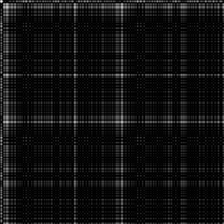

In [28]:
from IPython.display import display

sample = next(
    (GASF_DIR / "train" / "Normal").glob("*.png")
)

img = Image.open(sample)

display(
    img
)

In [29]:
print(
    "Image size:",
    img.size
)
print("Mode:", img.mode)
print("Channels:", len(img.getbands()))
print("Size:", img.size)

Image size: (224, 224)
Mode: L
Channels: 1
Size: (224, 224)


In [43]:
#from pathlib import Path

#DATA_DIR = Path(r"C:\Users\ankus\OneDrive\Documents\222026\IT\Awdhootprasad\Kurtosis\Data\12k_DE_fault")

all_mat_files = []

# -------------------------
# Ball fault: all parameters
# -------------------------
for param in ["007", "014", "021"]:
    all_mat_files.extend(
        sorted((DATA_DIR / "Ball fault").glob(f"B{param}_*.mat"))
    )

# -------------------------
# Inner race: all parameters
# -------------------------
for param in ["007", "014", "021"]:
    all_mat_files.extend(
        sorted((DATA_DIR / "Inner race").glob(f"IR{param}_*.mat"))
    )

# -------------------------
# Outer race: only @6
# -------------------------
for param in ["007", "014", "021"]:
    all_mat_files.extend(
        sorted((DATA_DIR / "Outer race").glob(f"OR{param}@6_*.mat"))
    )

print("Total .mat files:", len(all_mat_files))

for file in all_mat_files:
    print(file)
print("Total selected .mat files:", len(all_mat_files))

Total .mat files: 36
C:\Users\ankus\OneDrive\Documents\222026\IT\Awdhootprasad\Kurtosis\Data\12k_DE_fault\Ball fault\B007_0.mat
C:\Users\ankus\OneDrive\Documents\222026\IT\Awdhootprasad\Kurtosis\Data\12k_DE_fault\Ball fault\B007_1.mat
C:\Users\ankus\OneDrive\Documents\222026\IT\Awdhootprasad\Kurtosis\Data\12k_DE_fault\Ball fault\B007_2.mat
C:\Users\ankus\OneDrive\Documents\222026\IT\Awdhootprasad\Kurtosis\Data\12k_DE_fault\Ball fault\B007_3.mat
C:\Users\ankus\OneDrive\Documents\222026\IT\Awdhootprasad\Kurtosis\Data\12k_DE_fault\Ball fault\B014_0.mat
C:\Users\ankus\OneDrive\Documents\222026\IT\Awdhootprasad\Kurtosis\Data\12k_DE_fault\Ball fault\B014_1.mat
C:\Users\ankus\OneDrive\Documents\222026\IT\Awdhootprasad\Kurtosis\Data\12k_DE_fault\Ball fault\B014_2.mat
C:\Users\ankus\OneDrive\Documents\222026\IT\Awdhootprasad\Kurtosis\Data\12k_DE_fault\Ball fault\B014_3.mat
C:\Users\ankus\OneDrive\Documents\222026\IT\Awdhootprasad\Kurtosis\Data\12k_DE_fault\Ball fault\B021_0.mat
C:\Users\ankus\O

In [30]:
from collections import Counter

print(
    Counter(
        mat_file.parent.name
        for mat_file in all_mat_files
    )
)

NameError: name 'all_mat_files' is not defined

In [45]:
for mat_file in all_mat_files:
    print(mat_file.parent.name, "->", mat_file.name)

Ball fault -> B007_0.mat
Ball fault -> B007_1.mat
Ball fault -> B007_2.mat
Ball fault -> B007_3.mat
Ball fault -> B014_0.mat
Ball fault -> B014_1.mat
Ball fault -> B014_2.mat
Ball fault -> B014_3.mat
Ball fault -> B021_0.mat
Ball fault -> B021_1.mat
Ball fault -> B021_2.mat
Ball fault -> B021_3.mat
Inner race -> IR007_0.mat
Inner race -> IR007_1.mat
Inner race -> IR007_2.mat
Inner race -> IR007_3.mat
Inner race -> IR014_0.mat
Inner race -> IR014_1.mat
Inner race -> IR014_2.mat
Inner race -> IR014_3.mat
Inner race -> IR021_0.mat
Inner race -> IR021_1.mat
Inner race -> IR021_2.mat
Inner race -> IR021_3.mat
Outer race -> OR007@6_0.mat
Outer race -> OR007@6_1.mat
Outer race -> OR007@6_2.mat
Outer race -> OR007@6_3.mat
Outer race -> OR014@6_0.mat
Outer race -> OR014@6_1.mat
Outer race -> OR014@6_2.mat
Outer race -> OR014@6_3.mat
Outer race -> OR021@6_0.mat
Outer race -> OR021@6_1.mat
Outer race -> OR021@6_2.mat
Outer race -> OR021@6_3.mat


In [ ]:
def count_windows(signal_length):
    train_end = int(0.70 * signal_length)
    val_end = int(0.85 * signal_length)

    train_count = max(
        0,
        len(range(
            0,
            train_end - WINDOW_SIZE + 1,
            TRAIN_STEP
        ))
    )

    val_count = max(0,len(range(train_end,val_end - WINDOW_SIZE + 1,VAL_STEP)))

    test_count = max(0,len(range(val_end,signal_length - WINDOW_SIZE + 1,TEST_STEP)))

    return train_count, val_count, test_count

In [47]:
results = []

for mat_file in all_mat_files:

    signal = load_signal(mat_file)

    train_count, val_count, test_count = count_windows(
        len(signal)
    )

    class_name = get_class_name(
        mat_file,
        mat_file.parent.name
    )

    results.append({
        "file": mat_file.name,
        "class": class_name,
        "length": len(signal),
        "train": train_count,
        "val": val_count,
        "test": test_count
    })

In [58]:
import pandas as pd

df_counts = pd.DataFrame(results)

print(df_counts)

             file   class  length  train  val  test
0      B007_0.mat   B_007  122571    166   17    17
1      B007_1.mat   B_007  121410    164   17    17
2      B007_2.mat   B_007  121556    165   17    17
3      B007_3.mat   B_007  121556    165   17    17
4      B014_0.mat   B_014  121846    165   17    17
5      B014_1.mat   B_014  122136    165   17    17
6      B014_2.mat   B_014  121991    165   17    17
7      B014_3.mat   B_014  122136    165   17    17
8      B021_0.mat   B_021  121991    165   17    17
9      B021_1.mat   B_021  121701    165   17    17
10     B021_2.mat   B_021  122136    165   17    17
11     B021_3.mat   B_021  122136    165   17    17
12    IR007_0.mat  IR_007  121265    164   17    17
13    IR007_1.mat  IR_007  121991    165   17    17
14    IR007_2.mat  IR_007  122136    165   17    17
15    IR007_3.mat  IR_007  122917    167   18    18
16    IR014_0.mat  IR_014  121846    165   17    17
17    IR014_1.mat  IR_014  121846    165   17    17
18    IR014_

In [59]:
class_counts = (
    df_counts
    .groupby("class")[["train", "val", "test"]]
    .sum()
)

print(class_counts)

        train  val  test
class                   
B_007     660   68    68
B_014     660   68    68
B_021     660   68    68
IR_007    661   69    69
IR_014    660   68    68
IR_021    660   68    68
OR_007    661   68    68
OR_014    660   68    68
OR_021    662   68    68


In [51]:
class_counts["total"] = class_counts.sum(axis=1)

print(class_counts)

        train  val  test  total
class                          
B_007     660   68    68    796
B_014     660   68    68    796
B_021     660   68    68    796
IR_007    661   69    69    799
IR_014    660   68    68    796
IR_021    660   68    68    796
OR_007    661   68    68    797
OR_014    660   68    68    796
OR_021    662   68    68    798


In [32]:
# for i, mat_file in enumerate(all_mat_files):

#     print(f"\n{'='*60}")

#     print(f"File {i+1}/{len(all_mat_files)}")

#     print(f"{mat_file}")

#     process_mat_file(mat_file)

normal_files = [
    DATA_DIR / "97.mat",
    DATA_DIR / "98.mat",
    DATA_DIR / "99.mat",
    DATA_DIR / "100.mat"
]

for mat_file in normal_files:

    # print(f"\n{'='*60}")

    # print(f"File {i+1}/{len(all_mat_files)}")

    # print(f"{mat_file}")

    process_mat_file(mat_file)


Processing: 97.mat
Class: Normal
Signal length: 243,938
train: 165 windows
val: 17 windows
test: 17 windows

Processing: 98.mat
Class: Normal
Signal length: 483,903
train: 165 windows
val: 17 windows
test: 17 windows

Processing: 99.mat
Class: Normal
Signal length: 483,903
train: 165 windows
val: 17 windows
test: 17 windows

Processing: 100.mat
Class: Normal
Signal length: 485,643
train: 165 windows
val: 17 windows
test: 17 windows


In [56]:
normal_mat_files = sorted(
    (DATA_DIR / "normal").glob("*.mat")
)

print("Normal .mat files:", len(normal_mat_files))

for f in normal_mat_files:
    signal = load_signal(f)
    print(f.name, len(signal))

Normal .mat files: 4
100.mat 485643
97.mat 243938
98.mat 483903
99.mat 483903
